In [8]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS']= '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras as kr
from keras.callbacks import EarlyStopping



In [9]:
set_date_antrenare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/train',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

set_date_validare = kr.utils.image_dataset_from_directory(
    'D:/Licenta/DataSetOrganized/data/validation',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 3200 files belonging to 5 classes.
Found 400 files belonging to 5 classes.


In [10]:
model_data_augumentation = kr.Sequential([kr.layers.RandomFlip("horizontal_and_vertical"),kr.layers.RandomZoom(0.2),kr.layers.RandomRotation(0.2)])

In [11]:
model_antrenare = kr.models.Sequential()

model_antrenare.add(kr.layers.Input(shape=(256,256,3)))
model_antrenare.add(model_data_augumentation)
model_antrenare.add(kr.layers.Rescaling(1./255))

model_antrenare.add(kr.layers.Conv2D(filters=32, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.Conv2D(filters=32, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Conv2D(filters=64, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.Conv2D(filters=64,kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.Conv2D(filters=128, kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.Conv2D(filters=128,kernel_size= 3, padding='same'))
model_antrenare.add(kr.layers.BatchNormalization())
model_antrenare.add(kr.layers.Activation('relu'))
model_antrenare.add(kr.layers.MaxPooling2D(pool_size=2,strides=2))

model_antrenare.add(kr.layers.GlobalAveragePooling2D())

model_antrenare.add(kr.layers.Dense(256, activation='relu',kernel_regularizer=kr.regularizers.l2(0.001)))
model_antrenare.add(kr.layers.Dropout(0.5))

model_antrenare.add(kr.layers.Dense(5, activation='softmax'))

model_antrenare.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy',metrics=['accuracy'])

early_stop = kr.callbacks.EarlyStopping(monitor='val_loss', patience=10, verbose=1,restore_best_weights=True)

model_antrenare.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,213 (1.23 MB)

 Trainable params: 321,765 (1.23 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
model_antrenare_istoric = model_antrenare.fit(x=set_date_antrenare,validation_data = set_date_validare,epochs=25,callbacks=[early_stop])

Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.4894 - loss: 1.3854 - val_accuracy: 0.2000 - val_loss: 1.9570
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.6047 - loss: 1.1658 - val_accuracy: 0.2000 - val_loss: 2.8993
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.6253 - loss: 1.0841 - val_accuracy: 0.2000 - val_loss: 3.5516
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.6609 - loss: 1.0314 - val_accuracy: 0.2050 - val_loss: 2.8451
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.6644 - loss: 0.9980 - val_accuracy: 0.2925 - val_loss: 1.7412
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.6778 - loss: 0.9620 - val_accuracy: 0.4550 - val_loss: 1.2919
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.6881 - loss: 0.9405 - val_accuracy: 0.5100 - val_loss: 1.1934
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.7006 - loss: 0.9101 - val_accu

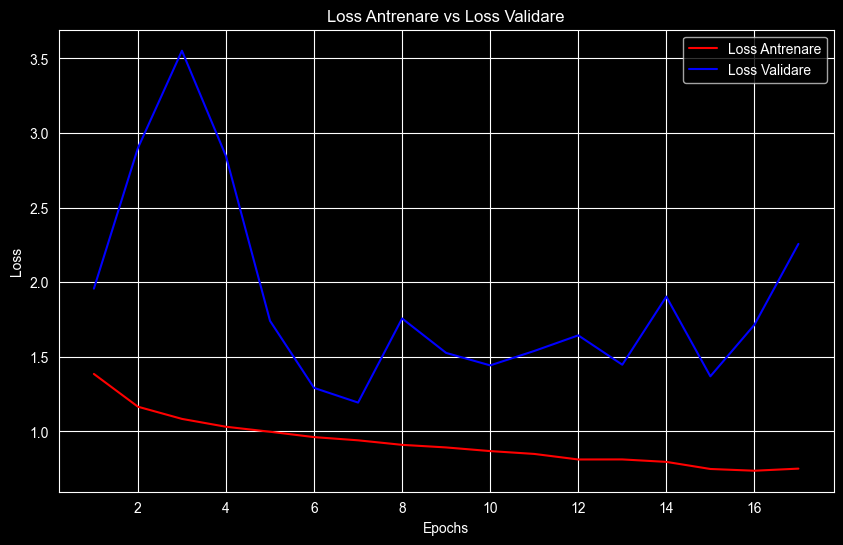

In [13]:
loss = model_antrenare_istoric.history['loss']
val_loss = model_antrenare_istoric.history['val_loss']
epochs = range(1, len(loss) + 1)


plt.figure(figsize = (10,6))
plt.plot(epochs, loss, 'r', label='Loss Antrenare')
plt.plot(epochs, val_loss, 'b', label='Loss Validare')
plt.title('Loss Antrenare vs Loss Validare')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

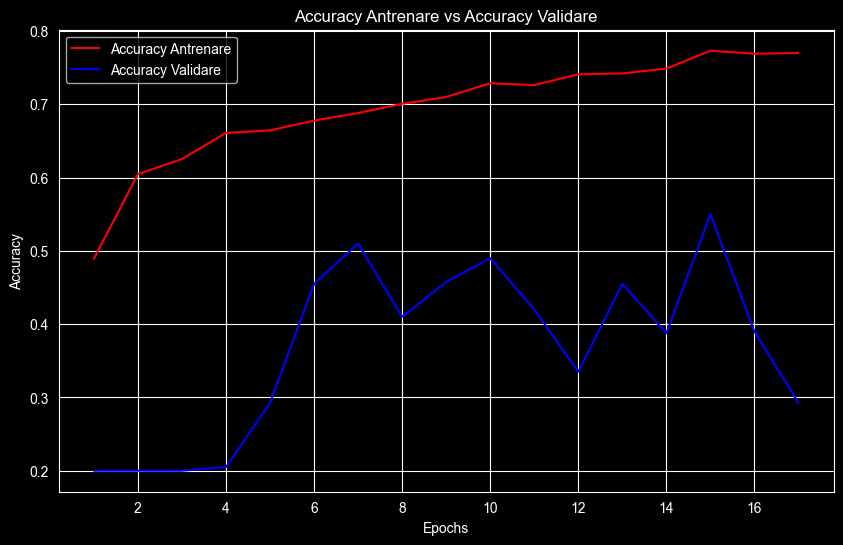

In [14]:
accuracy = model_antrenare_istoric.history['accuracy']
val_accuracy = model_antrenare_istoric.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)


plt.figure(figsize = (10,6))
plt.plot(epochs, accuracy, 'r', label='Accuracy Antrenare')
plt.plot(epochs, val_accuracy, 'b', label='Accuracy Validare')
plt.title('Accuracy Antrenare vs Accuracy Validare')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()